In [1]:
import os
from image_prepare import pre_images

path = "Data/"
data = []
labels = []
for clss in os.listdir(path):
    class_path = os.path.join(path, clss)
    if not os.path.isdir(class_path):
        continue
    for image_name in os.listdir(class_path):
        img = pre_images((512, 512), os.path.join(class_path, image_name))
        data.append(img)
        labels.append(clss)

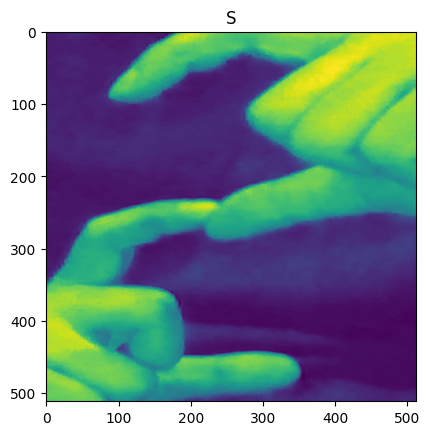

In [2]:
import matplotlib.pyplot as plt
import random as rnd

num = rnd.randint(0, len(data))
fig = plt.figure()
plt.title(labels[num])
plt.imshow(data[num])

In [3]:
import numpy as np

x_train = np.copy(data)
y_train = np.copy(labels)

In [4]:
import albumentations as A

aug = A.Compose([
    A.Rotate(limit=30, p=0.5),
    A.Affine(scale=(0.8, 1.2), translate_percent=(0.1, 0.1), rotate=(-30, 30), shear=(-15, 15), p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.RandomSizedCrop(min_max_height=(128, 256), p=0.3, size=(512, 512)),
    A.Resize(height=512, width=512),
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3)
])

batch_size = 100

for start in range(0, len(x_train), batch_size):
    end = min(start + batch_size, len(x_train))

    x_aug = np.copy(x_train[start:end])
    y_aug_label = np.copy(y_train[start:end])

    for i in range(len(x_aug)):
        augmented = aug(image=x_aug[i, :, :, :])
        x_aug[i, :, :, :] = augmented['image']

    x_train = np.concatenate((x_train, x_aug))
    y_train = np.concatenate((y_train, y_aug_label))

In [5]:
del x_aug
del data
del labels
del augmented

In [6]:
from model import TslNET

model = TslNET()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 510, 510, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 253, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 124, 124, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 492032)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    62,980,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,076,637 (240.62 MB)

 Trainable params: 63,076,637 (240.62 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [8]:
from keras._tf_keras.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

encoded_y_train = label_encoder.fit_transform(y_train)

encoded_y_train = to_categorical(encoded_y_train, num_classes=29)

In [9]:
model.fit(x_train,encoded_y_train,batch_size=8,epochs=1,verbose=1)

747/747 ━━━━━━━━━━━━━━━━━━━━ 2354s 3s/step - accuracy: 0.0334 - loss: 3.5990


In [51]:
num = rnd.randint(0,len(x_train))

image = x_train[num].reshape(1, 512, 512, 1)
pred = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step


In [52]:
np.argmax(pred)

np.int64(0)

Text(0.5, 1.0, 'R')

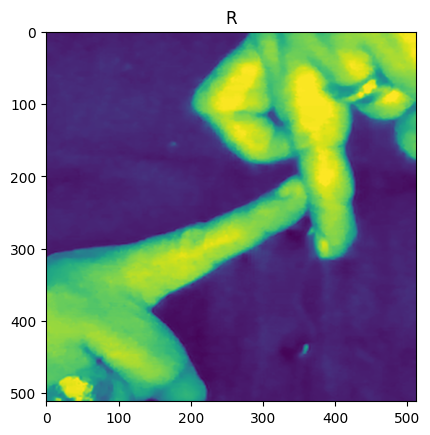

In [53]:
plt.imshow(x_train[num])
plt.title(y_train[num])